<a href="https://colab.research.google.com/github/justamy20/finalterm-machine-learning/blob/main/Fraud_Detection_Deep_Learning_FinalTerm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Deep Learning Pipeline — Online Transaction Fraud Detection

**"Hands-On End-to-End Models Deep Learning"** — Final Term Individual Task (Machine Learning Class)

---

###  Student Identification
- **Name:** `Syeh Khatami`
- **Class:** `TK-47-04`
- **NIM:** `101032300157`

---

## 1. Main Objective
To design and implement an **end-to-end deep learning pipeline** that predicts the probability of an online transaction being fraudulent (`isFraud`), using the IEEE-CIS style transaction + identity dataset.

## 2. Task Overview
This notebook covers the complete workflow:
1. Data loading (`train_transaction.csv` + `train_identity.csv`) from Google Drive
2. Exploratory Data Analysis (EDA)
3. Data cleaning & preprocessing (missing values, class imbalance)
4. Feature engineering & feature selection
5. Building **3 different deep learning architectures**:
   - **Model A — Shallow MLP** (baseline deep learning model)
   - **Model B — Deep MLP** with Batch Normalization + Dropout (tests effect of depth/regularization)
   - **Model C — 1D-CNN for Tabular Data** (treats the feature vector as a 1D signal to capture local feature interactions)
6. Hyperparameter tuning using **Optuna**
7. Experiment tracking using **MLflow**
8. Evaluation using metrics appropriate for **imbalanced classification** (PR-AUC, ROC-AUC, F1, Recall, Precision, Confusion Matrix)
9. Comparison of all 3 architectures + conclusions

> 💡 **Why these 3 architectures?** The dataset is **tabular**, not image/text/sequence data tied to a time axis. So instead of arbitrarily comparing CNN vs RNN vs Transformer (which are designed for spatial/sequential data), we compare three deep learning designs that are all legitimate and commonly used **for tabular data**, varying in capacity and inductive bias — this gives a meaningful, defensible comparison for a tabular fraud-detection problem.


---
## 0. Environment Setup

Run this section first. It will:
- Install required libraries not pre-installed on Colab (`optuna`, `mlflow`, `pyngrok` is NOT needed — we track locally)
- Mount Google Drive so we can read the dataset files
- Set random seeds for reproducibility


In [10]:
# Install extra libraries not pre-installed on Google Colab
!pip install -q optuna mlflow scikit-learn==1.5.2 imbalanced-learn


In [11]:
# Core imports
import os
import gc
import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    classification_report, precision_recall_curve, roc_curve
)

import optuna
from optuna.samplers import TPESampler

import mlflow
import mlflow.pytorch

print("Torch version       :", torch.__version__)
print("CUDA available       :", torch.cuda.is_available())
print("Optuna version       :", optuna.__version__)
print("MLflow version       :", mlflow.__version__)


Torch version       : 2.11.0+cu128
CUDA available       : True
Optuna version       : 4.9.0
MLflow version       : 3.14.0


In [12]:
# Reproducibility
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


In [13]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Ubah bagian ini sesuai nama folder di Drive kamu
DATA_DIR = "/content/drive/MyDrive/fraud_dataset"

print("Files in DATA_DIR:")
print(os.listdir(DATA_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in DATA_DIR:
['train_transaction (1).csv', 'test_transaction.csv', 'train_identity.csv', 'test_identity.csv']


---
## 1. Data Loading

We load both the **transaction** table and the **identity** table, then merge them on `TransactionID`.
Not every transaction has a matching identity record (identity data is optional at checkout), so we use a **left join** keeping all transactions.


In [14]:
t0 = time.time()

# Baris ini sudah diubah sesuai dengan nama file di Drive
df_transaction = pd.read_csv(os.path.join(DATA_DIR, "train_transaction (1).csv"))

# Pastikan file train_identity.csv sudah kamu upload ke folder fraud_dataset!
df_identity = pd.read_csv(os.path.join(DATA_DIR, "train_identity.csv"))

print(f"train_transaction shape : {df_transaction.shape}")
print(f"train_identity shape    : {df_identity.shape}")
print(f"Loaded in {time.time() - t0:.1f}s")

train_transaction shape : (590540, 394)
train_identity shape    : (144233, 41)
Loaded in 44.2s


In [15]:
# Merge on TransactionID (left join — keep all transactions even without identity info)
df = df_transaction.merge(df_identity, on="TransactionID", how="left")
print("Merged shape:", df.shape)

del df_transaction, df_identity
gc.collect()

df.head()


Merged shape: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [16]:
# Fungsi untuk mengecilkan ukuran data (downcasting) agar tidak OOM
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory pemakaian awal: {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory pemakaian setelah optimasi: {end_mem:.2f} MB')
    return df

# Terapkan fungsi ke dataframe kita
df = reduce_mem_usage(df)

Memory pemakaian awal: 1955.37 MB
Memory pemakaian setelah optimasi: 645.97 MB


---
## 2. Exploratory Data Analysis (EDA)

Before preprocessing, we explore:
- Target class balance (`isFraud`)
- Missing value patterns
- Distribution of transaction amount
- Data types overview


Target distribution (isFraud):
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.499%


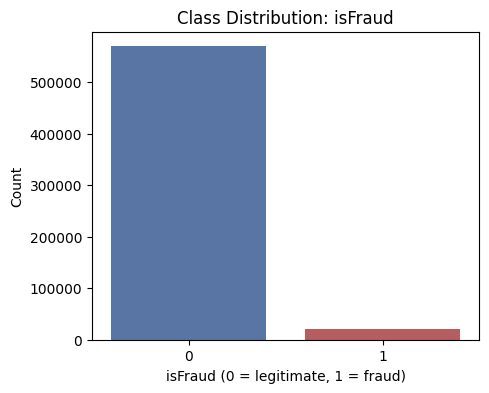

In [17]:
print("Target distribution (isFraud):")
print(df['isFraud'].value_counts())
print()
print("Fraud rate: {:.3f}%".format(df['isFraud'].mean() * 100))

plt.figure(figsize=(5,4))
sns.countplot(x='isFraud', data=df, palette=['#4C72B0', '#C44E52'])
plt.title("Class Distribution: isFraud")
plt.xlabel("isFraud (0 = legitimate, 1 = fraud)")
plt.ylabel("Count")
plt.show()


Top 20 columns by % missing values:
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_22    99.124699
id_27    99.124699
id_23    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
D8       87.312290
dtype: float64


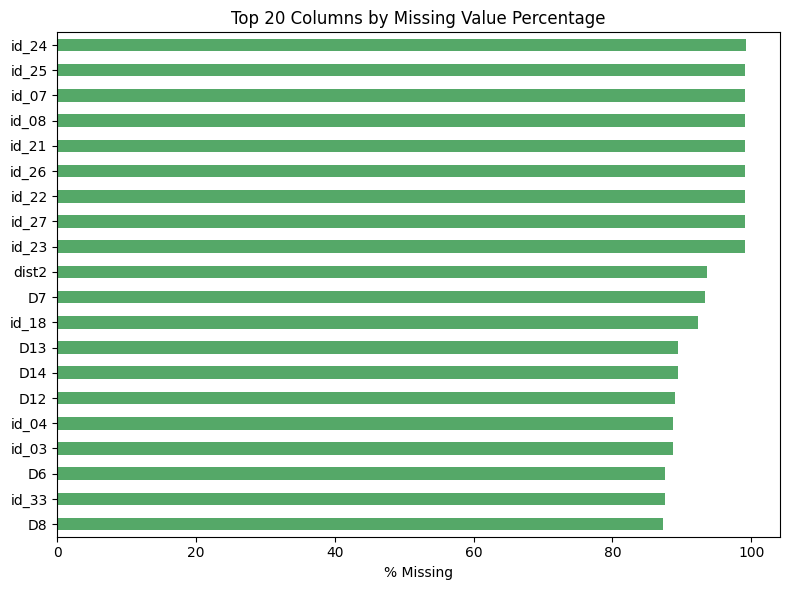

In [18]:
# Missing value overview (top 20 columns with most missing values)
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
print("Top 20 columns by % missing values:")
print(missing_pct.head(20))

plt.figure(figsize=(8,6))
missing_pct.head(20).plot(kind='barh', color='#55A868')
plt.gca().invert_yaxis()
plt.xlabel("% Missing")
plt.title("Top 20 Columns by Missing Value Percentage")
plt.tight_layout()
plt.show()


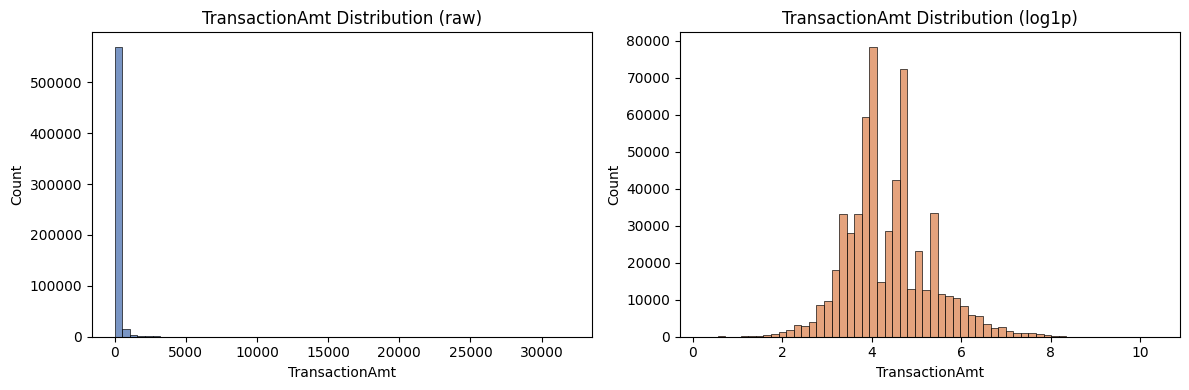

In [19]:
# TransactionAmt distribution (log scale because heavily right-skewed)
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['TransactionAmt'], bins=60, color='#4C72B0')
plt.title("TransactionAmt Distribution (raw)")

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['TransactionAmt']), bins=60, color='#DD8452')
plt.title("TransactionAmt Distribution (log1p)")

plt.tight_layout()
plt.show()


In [20]:
# Data types overview
print("Data type counts:")
print(df.dtypes.value_counts())
print()
print(f"Total columns: {df.shape[1]}")
print(f"Numeric columns: {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"Categorical (object) columns: {df.select_dtypes(include=['object']).shape[1]}")


Data type counts:
float16    354
float32     45
object      31
int32        2
int8         1
int16        1
Name: count, dtype: int64

Total columns: 434
Numeric columns: 403
Categorical (object) columns: 31


---
## 3. Data Cleaning & Preprocessing

Steps performed here:
1. Drop columns with **extremely high missing rate** (> 90%) — not enough signal to impute reliably
2. Separate numeric vs categorical columns
3. Impute missing values (median for numeric, constant `"missing"` for categorical)
4. Encode categorical columns with `OrdinalEncoder`
5. Train / validation / test split (stratified, because of class imbalance)
6. Scale numeric features with `StandardScaler`


In [21]:
# Step 1: Drop columns with too many missing values
HIGH_MISSING_THRESHOLD = 0.90
cols_to_drop = missing_pct[missing_pct > HIGH_MISSING_THRESHOLD * 100].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with > {HIGH_MISSING_THRESHOLD*100:.0f}% missing values")

df = df.drop(columns=cols_to_drop)
print("Shape after dropping high-missing columns:", df.shape)


Dropping 12 columns with > 90% missing values
Shape after dropping high-missing columns: (590540, 422)


In [22]:
# Step 2: Separate target, identifier, numeric and categorical columns
TARGET = "isFraud"
ID_COL = "TransactionID"

feature_cols = [c for c in df.columns if c not in [TARGET, ID_COL]]

categorical_cols = df[feature_cols].select_dtypes(include=['object']).columns.tolist()
numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeric features     : {len(numeric_cols)}")
print(f"Categorical features : {len(categorical_cols)}")


Numeric features     : 391
Categorical features : 29


In [23]:
# Step 3: Impute missing values
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df[categorical_cols] = df[categorical_cols].fillna("missing")

print("Remaining missing values after imputation:", df[feature_cols].isnull().sum().sum())


Remaining missing values after imputation: 0


In [24]:
# Step 4: Encode categorical columns
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df[categorical_cols] = encoder.fit_transform(df[categorical_cols])

print("Categorical columns encoded. Sample:")
df[categorical_cols].head()


Categorical columns encoded. Sample:


,ProductCD,card4,card6,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,...,id_30,id_31,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,4.0,1.0,1.0,31.0,31.0,1.0,1.0,1.0,2.0,0.0,...,74.0,96.0,260.0,4.0,2.0,2.0,2.0,2.0,1.0,1735.0
1,4.0,2.0,1.0,16.0,31.0,2.0,2.0,2.0,0.0,1.0,...,74.0,96.0,260.0,4.0,2.0,2.0,2.0,2.0,1.0,1735.0
2,4.0,4.0,2.0,36.0,31.0,1.0,1.0,1.0,0.0,0.0,...,74.0,96.0,260.0,4.0,2.0,2.0,2.0,2.0,1.0,1735.0
3,4.0,2.0,2.0,54.0,31.0,2.0,2.0,2.0,0.0,1.0,...,74.0,96.0,260.0,4.0,2.0,2.0,2.0,2.0,1.0,1735.0
4,1.0,2.0,1.0,16.0,31.0,2.0,2.0,2.0,3.0,2.0,...,7.0,124.0,164.0,3.0,1.0,0.0,1.0,1.0,2.0,954.0


In [25]:
# Step 5: Train / Validation / Test split (stratified due to class imbalance)
X = df[feature_cols].values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train shape : {X_train.shape}, fraud rate: {y_train.mean():.4f}")
print(f"Val shape   : {X_val.shape}, fraud rate: {y_val.mean():.4f}")
print(f"Test shape  : {X_test.shape}, fraud rate: {y_test.mean():.4f}")


Train shape : (413378, 420), fraud rate: 0.0350
Val shape   : (88581, 420), fraud rate: 0.0350
Test shape  : (88581, 420), fraud rate: 0.0350


In [26]:
# Step 6: Scale numeric features (fit only on train to avoid data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Scaling complete.")
print("Train mean ~0:", np.round(X_train.mean(), 3), "| Train std ~1:", np.round(X_train.std(), 3))


Scaling complete.
Train mean ~0: 0.0 | Train std ~1: 1.0


---
## 4. Feature Engineering & Class Imbalance Handling

### 4.1 Feature Engineering
We already engineered/selected features implicitly through:
- Dropping uninformative (>90% missing) columns
- Encoding categorical card/address/device features
- Using the log-scale-aware `TransactionAmt`

### 4.2 Handling Class Imbalance
Fraud is rare (~3.5% positive class). We handle this with a **WeightedRandomSampler** during training (oversamples the minority/fraud class within each batch) rather than naive oversampling/SMOTE on raw tabular data — this avoids creating unrealistic synthetic fraud patterns and works cleanly with PyTorch `DataLoader`.


In [27]:
# Compute class weights for the WeightedRandomSampler
class_counts = np.bincount(y_train.astype(int))
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_train.astype(int)]

print("Class counts (train):", class_counts)
print("Class weights        :", class_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


Class counts (train): [398914  14464]
Class weights        : [2.50680598e-06 6.91371681e-05]


In [28]:
# PyTorch Dataset wrapper
class FraudDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = FraudDataset(X_train, y_train)
val_ds = FraudDataset(X_val, y_val)
test_ds = FraudDataset(X_test, y_test)

BATCH_SIZE = 512

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

INPUT_DIM = X_train.shape[1]
print("Input feature dimension:", INPUT_DIM)


Input feature dimension: 420


---
## 5. Deep Learning Model Architectures

We define and will compare **3 architectures**, all suited for tabular data:

| Model | Description | Hypothesis |
|---|---|---|
| **A — Shallow MLP** | 2 hidden layers, ReLU, Dropout | Baseline deep learning model |
| **B — Deep MLP** | 5 hidden layers, BatchNorm + Dropout | Tests whether more depth + regularization improves fraud detection |
| **C — 1D-CNN Tabular** | Treats the feature vector as a 1D sequence and applies 1D convolutions to capture local feature interactions | Tests whether convolutional inductive bias helps on tabular data |


In [29]:
# ---------------------------------------------------------------
# Model A: Shallow MLP (baseline)
# ---------------------------------------------------------------
class ShallowMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


In [30]:
# ---------------------------------------------------------------
# Model B: Deep MLP with BatchNorm + Dropout
# ---------------------------------------------------------------
class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.3, n_layers=5):
        super().__init__()
        layers = []
        in_dim = input_dim
        for i in range(n_layers):
            out_dim = max(hidden_dim // (2 ** min(i, 3)), 16)
            layers += [
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            in_dim = out_dim
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


In [31]:
# ---------------------------------------------------------------
# Model C: 1D-CNN for Tabular Data
# Treats the feature vector (length = INPUT_DIM) as a 1-channel
# 1D "signal" so convolutions can learn local interactions between
# adjacent engineered features.
# ---------------------------------------------------------------
class TabularCNN(nn.Module):
    def __init__(self, input_dim, n_filters=32, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, n_filters, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(n_filters)
        self.conv2 = nn.Conv1d(n_filters, n_filters * 2, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(n_filters * 2)
        self.pool = nn.AdaptiveAvgPool1d(8)  # fixed-size output regardless of input_dim
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(n_filters * 2 * 8, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        # x: (batch, input_dim) -> (batch, 1, input_dim)
        x = x.unsqueeze(1)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = x.flatten(1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x.squeeze(-1)


In [32]:
# Quick sanity check: forward pass with dummy batch
dummy = torch.randn(8, INPUT_DIM)

for name, model_cls in [("ShallowMLP", ShallowMLP), ("DeepMLP", DeepMLP), ("TabularCNN", TabularCNN)]:
    m = model_cls(INPUT_DIM)
    out = m(dummy)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:12s} | output shape: {tuple(out.shape)} | trainable params: {n_params:,}")


ShallowMLP   | output shape: (8,) | trainable params: 29,057
DeepMLP      | output shape: (8,) | trainable params: 65,553
TabularCNN   | output shape: (8,) | trainable params: 39,489


---
## 6. Training & Evaluation Utilities

We define reusable functions for:
- `train_one_epoch` / `evaluate` — generic training & validation loop for any of the 3 models
- `compute_metrics` — appropriate metrics for **imbalanced binary classification**:
  - **ROC-AUC** — overall ranking quality
  - **PR-AUC (Average Precision)** — more informative than ROC-AUC under heavy class imbalance
  - **Precision, Recall, F1** at threshold 0.5
  - **Confusion Matrix**


In [33]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_probs, all_targets = [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_targets.append(yb.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)
    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(all_targets, all_probs)
    metrics["loss"] = avg_loss
    return metrics, all_probs, all_targets


def train_model(model, train_loader, val_loader, lr=1e-3, weight_decay=1e-5,
                 n_epochs=15, patience=4, verbose=True):
    """Generic training loop with early stopping on validation PR-AUC."""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    best_pr_auc = -np.inf
    best_state = None
    epochs_no_improve = 0
    history = []

    for epoch in range(1, n_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_metrics, _, _ = evaluate(model, val_loader, criterion)
        history.append({"epoch": epoch, "train_loss": train_loss, **val_metrics})

        if verbose:
            print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
                  f"val_loss={val_metrics['loss']:.4f} | val_pr_auc={val_metrics['pr_auc']:.4f} | "
                  f"val_roc_auc={val_metrics['roc_auc']:.4f} | val_f1={val_metrics['f1']:.4f}")

        if val_metrics["pr_auc"] > best_pr_auc:
            best_pr_auc = val_metrics["pr_auc"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_pr_auc


---
## 7. MLflow Experiment Tracking Setup

We use **MLflow** to log, for every training run:
- Hyperparameters (learning rate, hidden dim, dropout, etc.)
- Metrics (loss, ROC-AUC, PR-AUC, F1, Precision, Recall) per epoch and final
- The trained model artifact

On Colab, MLflow logs locally to `./mlruns`. To **view the MLflow UI inside Colab**, run the optional `pyngrok` cell below (needs a free ngrok account + authtoken) — or simply zip and download the `mlruns` folder to inspect locally with `mlflow ui`.


In [36]:
# Import os (opsional, tapi bagus untuk berjaga-jaga)
import os

# Ubah "file:./mlruns" menjadi database SQLite
mlflow.set_tracking_uri("sqlite:///mlflow.db")

EXPERIMENT_NAME = "fraud_detection_deep_learning"
mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Active experiment   :", EXPERIMENT_NAME)

2026/06/19 10:18:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/19 10:18:07 INFO mlflow.store.db.utils: Updating database tables
2026/06/19 10:18:10 INFO mlflow.tracking.fluent: Experiment with name 'fraud_detection_deep_learning' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:///mlflow.db
Active experiment   : fraud_detection_deep_learning


In [37]:
# OPTIONAL: expose the MLflow UI via ngrok tunnel directly inside Colab.
# Requires a free ngrok account -> https://dashboard.ngrok.com/get-started/your-authtoken
# Uncomment and fill in your own authtoken to use this.

# !pip install -q pyngrok
# from pyngrok import ngrok
# get_ipython().system_raw("mlflow ui --port 5000 &")
# ngrok.set_auth_token("YOUR_NGROK_AUTHTOKEN")
# public_url = ngrok.connect(5000)
# print("MLflow UI:", public_url)


---
## 8. Hyperparameter Tuning with Optuna

For **each of the 3 architectures**, we run an independent Optuna study that:
1. Samples hyperparameters (learning rate, hidden dimension, dropout, weight decay, batch size)
2. Trains the model for a few epochs
3. Returns validation **PR-AUC** as the objective to **maximize** (PR-AUC is the right choice here because of the severe class imbalance — ROC-AUC can look optimistic when negatives vastly outnumber positives)

We use a modest number of trials (`N_TRIALS`) and epochs per trial to keep runtime reasonable on Colab. Increase these if you have more compute/time budget.


In [38]:
N_TRIALS = 2          # number of Optuna trials per model architecture
TUNING_EPOCHS = 2      # epochs per trial during tuning (kept small for speed)
FINAL_EPOCHS = 5      # epochs for final training with the best hyperparameters
PATIENCE = 4


In [39]:
def make_loader(batch_size):
    """Re-create train/val loaders with a given batch size (used by Optuna trials)."""
    sampler_local = WeightedRandomSampler(
        weights=sample_weights, num_samples=len(sample_weights), replacement=True
    )
    tl = DataLoader(train_ds, batch_size=batch_size, sampler=sampler_local)
    vl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return tl, vl


def objective_factory(model_cls, model_name):
    """Returns an Optuna objective function for the given model class."""

    def objective(trial):
        set_seed(SEED)

        lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        batch_size = trial.suggest_categorical("batch_size", [256, 512, 1024])

        if model_name == "ShallowMLP":
            hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128])
            model = ShallowMLP(INPUT_DIM, hidden_dim=hidden_dim, dropout=dropout)
        elif model_name == "DeepMLP":
            hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256])
            n_layers = trial.suggest_int("n_layers", 3, 6)
            model = DeepMLP(INPUT_DIM, hidden_dim=hidden_dim, dropout=dropout, n_layers=n_layers)
        elif model_name == "TabularCNN":
            n_filters = trial.suggest_categorical("n_filters", [16, 32, 64])
            model = TabularCNN(INPUT_DIM, n_filters=n_filters, dropout=dropout)
        else:
            raise ValueError(model_name)

        tl, vl = make_loader(batch_size)

        _, _, best_pr_auc = train_model(
            model, tl, vl, lr=lr, weight_decay=weight_decay,
            n_epochs=TUNING_EPOCHS, patience=PATIENCE, verbose=False
        )

        return best_pr_auc

    return objective


---
## 9. Run Hyperparameter Tuning + Final Training (logged to MLflow)

For each architecture we:
1. Run an Optuna study (`N_TRIALS` trials)
2. Take the **best hyperparameters** found
3. Re-train the model with those hyperparameters for `FINAL_EPOCHS` epochs
4. Log everything (params, per-epoch metrics, final metrics, model artifact) to **MLflow**
5. Evaluate on the **held-out test set** (never seen during tuning/training)

This whole section may take a while to run on Colab — that's expected given 3 models × Optuna trials × multiple epochs. Consider switching the Colab runtime to GPU (`Runtime > Change runtime type > GPU`) to speed this up.


In [40]:
MODEL_REGISTRY = {
    "ShallowMLP": ShallowMLP,
    "DeepMLP": DeepMLP,
    "TabularCNN": TabularCNN,
}

results = {}        # model_name -> dict with test metrics, history, best_params
trained_models = {} # model_name -> trained torch model


In [54]:
def run_pipeline_for_model(model_name):
    print("=" * 70)
    print(f"Tuning + training: {model_name}")
    print("=" * 70)

    model_cls = MODEL_REGISTRY[model_name]

    # ---- 1. Optuna hyperparameter search ----
    study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
    study.optimize(objective_factory(model_cls, model_name), n_trials=N_TRIALS, show_progress_bar=True)

    best_params = study.best_params
    print(f"\nBest params for {model_name}: {best_params}")
    print(f"Best validation PR-AUC during tuning: {study.best_value:.4f}\n")

    # ---- 2. Re-create model with best hyperparameters ----
    set_seed(SEED)
    common_kwargs = dict(dropout=best_params["dropout"])

    if model_name == "ShallowMLP":
        model = ShallowMLP(INPUT_DIM, hidden_dim=best_params["hidden_dim"], **common_kwargs)
    elif model_name == "DeepMLP":
        model = DeepMLP(INPUT_DIM, hidden_dim=best_params["hidden_dim"],
                         n_layers=best_params["n_layers"], **common_kwargs)
    elif model_name == "TabularCNN":
        model = TabularCNN(INPUT_DIM, n_filters=best_params["n_filters"], **common_kwargs)

    tl, vl = make_loader(best_params["batch_size"])

    # ---- 3. Final training + MLflow logging ----
    with mlflow.start_run(run_name=model_name):
        mlflow.log_param("model_name", model_name)
        for k, v in best_params.items():
            mlflow.log_param(k, v)
        mlflow.log_param("final_epochs", FINAL_EPOCHS)
        mlflow.log_param("input_dim", INPUT_DIM)

        trained_model, history, best_val_pr_auc = train_model(
            model, tl, vl,
            lr=best_params["lr"], weight_decay=best_params["weight_decay"],
            n_epochs=FINAL_EPOCHS, patience=PATIENCE, verbose=True
        )

        for h in history:
            mlflow.log_metrics(
                {k: v for k, v in h.items() if k != "epoch"}, step=h["epoch"]
            )

       # ---- 4. Final evaluation on held-out TEST set ----
        criterion = nn.BCEWithLogitsLoss()
        test_metrics, test_probs, test_targets = evaluate(trained_model, test_loader, criterion)

        mlflow.log_metrics({f"test_{k}": v for k, v in test_metrics.items()})
        mlflow.pytorch.log_model(trained_model, name=f"model_{model_name}", serialization_format="pickle")

        print(f"\n[TEST SET] {model_name} metrics:")
        for k, v in test_metrics.items():
            print(f"   {k:10s}: {v:.4f}")

    results[model_name] = {
        "best_params": best_params,
        "history": history,
        "test_metrics": test_metrics,
        "test_probs": test_probs,
        "test_targets": test_targets,
        "study": study,
    }
    trained_models[model_name] = trained_model

    return trained_model, history, test_metrics

In [55]:
# Run for Model A: Shallow MLP
_ = run_pipeline_for_model("ShallowMLP")


[I 2026-06-19 10:29:02,659] A new study created in memory with name: no-name-98eab680-5acd-4eb5-8099-040a9f6d33dd


Tuning + training: ShallowMLP


  0%|          | 0/2 [00:00<?, ?it/s]

[I 2026-06-19 10:29:21,323] Trial 0 finished with value: 0.5260818201846736 and parameters: {'lr': 0.00043284502212938834, 'weight_decay': 0.0007114476009343421, 'dropout': 0.39279757672456206, 'batch_size': 256, 'hidden_dim': 64}. Best is trial 0 with value: 0.5260818201846736.
[I 2026-06-19 10:29:36,559] Trial 1 finished with value: 0.553882179326642 and parameters: {'lr': 0.0015958573588141277, 'weight_decay': 1.1527987128232402e-06, 'dropout': 0.4879639408647978, 'batch_size': 256, 'hidden_dim': 128}. Best is trial 1 with value: 0.553882179326642.

Best params for ShallowMLP: {'lr': 0.0015958573588141277, 'weight_decay': 1.1527987128232402e-06, 'dropout': 0.4879639408647978, 'batch_size': 256, 'hidden_dim': 128}
Best validation PR-AUC during tuning: 0.5539

Epoch 01 | train_loss=0.4412 | val_loss=0.3373 | val_pr_auc=0.5154 | val_roc_auc=0.8946 | val_f1=0.3200
Epoch 02 | train_loss=0.3983 | val_loss=0.3412 | val_pr_auc=0.5539 | val_roc_auc=0.9034 | val_f1=0.3173
Epoch 03 | train_los

2026/06/19 10:30:14 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/19 10:30:14 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/19 10:30:32 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version la


[TEST SET] ShallowMLP metrics:
   roc_auc   : 0.9181
   pr_auc    : 0.6052
   f1        : 0.3458
   precision : 0.2229
   recall    : 0.7702
   loss      : 0.3079


In [56]:
# Run for Model B: Deep MLP
_ = run_pipeline_for_model("DeepMLP")


[I 2026-06-19 10:30:55,858] A new study created in memory with name: no-name-b5de45f0-39d6-4b5a-8e6e-91fc716ec58a


Tuning + training: DeepMLP


  0%|          | 0/2 [00:00<?, ?it/s]

[I 2026-06-19 10:31:18,253] Trial 0 finished with value: 0.5221243490058342 and parameters: {'lr': 0.00043284502212938834, 'weight_decay': 0.0007114476009343421, 'dropout': 0.39279757672456206, 'batch_size': 256, 'hidden_dim': 128, 'n_layers': 5}. Best is trial 0 with value: 0.5221243490058342.
[I 2026-06-19 10:31:38,854] Trial 1 finished with value: 0.4692966225628337 and parameters: {'lr': 0.00010838581269344756, 'weight_decay': 0.0008123245085588687, 'dropout': 0.4329770563201687, 'batch_size': 256, 'hidden_dim': 128, 'n_layers': 4}. Best is trial 0 with value: 0.5221243490058342.

Best params for DeepMLP: {'lr': 0.00043284502212938834, 'weight_decay': 0.0007114476009343421, 'dropout': 0.39279757672456206, 'batch_size': 256, 'hidden_dim': 128, 'n_layers': 5}
Best validation PR-AUC during tuning: 0.5221

Epoch 01 | train_loss=0.5204 | val_loss=0.3830 | val_pr_auc=0.4787 | val_roc_auc=0.8796 | val_f1=0.3050
Epoch 02 | train_loss=0.4558 | val_loss=0.3462 | val_pr_auc=0.5221 | val_roc_a

2026/06/19 10:32:34 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/19 10:32:34 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/19 10:32:44 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version la


[TEST SET] DeepMLP metrics:
   roc_auc   : 0.9062
   pr_auc    : 0.5742
   f1        : 0.3497
   precision : 0.2283
   recall    : 0.7467
   loss      : 0.3288


In [57]:
# Run for Model C: 1D-CNN Tabular
_ = run_pipeline_for_model("TabularCNN")


[I 2026-06-19 10:32:54,728] A new study created in memory with name: no-name-e0fb9631-2b4d-4e68-963d-dec92be61cab


Tuning + training: TabularCNN


  0%|          | 0/2 [00:00<?, ?it/s]

[I 2026-06-19 10:33:24,361] Trial 0 finished with value: 0.34182413422420627 and parameters: {'lr': 0.00043284502212938834, 'weight_decay': 0.0007114476009343421, 'dropout': 0.39279757672456206, 'batch_size': 256, 'n_filters': 32}. Best is trial 0 with value: 0.34182413422420627.
[I 2026-06-19 10:34:21,188] Trial 1 finished with value: 0.3986587085812614 and parameters: {'lr': 0.0015958573588141277, 'weight_decay': 1.1527987128232402e-06, 'dropout': 0.4879639408647978, 'batch_size': 256, 'n_filters': 64}. Best is trial 1 with value: 0.3986587085812614.

Best params for TabularCNN: {'lr': 0.0015958573588141277, 'weight_decay': 1.1527987128232402e-06, 'dropout': 0.4879639408647978, 'batch_size': 256, 'n_filters': 64}
Best validation PR-AUC during tuning: 0.3987

Epoch 01 | train_loss=0.5112 | val_loss=0.4471 | val_pr_auc=0.3528 | val_roc_auc=0.8367 | val_f1=0.2048
Epoch 02 | train_loss=0.4855 | val_loss=0.4237 | val_pr_auc=0.3978 | val_roc_auc=0.8543 | val_f1=0.2324
Epoch 03 | train_loss

2026/06/19 10:36:49 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/19 10:36:49 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/19 10:36:56 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version la


[TEST SET] TabularCNN metrics:
   roc_auc   : 0.8727
   pr_auc    : 0.4587
   f1        : 0.2524
   precision : 0.1527
   recall    : 0.7264
   loss      : 0.4117


---
## 10. Model Comparison & Evaluation

Now we compare all 3 trained architectures side-by-side on the **held-out test set** using:
- Summary metrics table
- ROC curves (overlaid)
- Precision-Recall curves (overlaid) — most important given class imbalance
- Confusion matrices (side-by-side)


In [58]:
# Summary table of test metrics across all 3 models
summary_df = pd.DataFrame({
    name: res["test_metrics"] for name, res in results.items()
}).T
summary_df = summary_df[["roc_auc", "pr_auc", "f1", "precision", "recall", "loss"]]
summary_df = summary_df.sort_values("pr_auc", ascending=False)

print("=== Model Comparison: Test Set Metrics ===")
summary_df.round(4)


=== Model Comparison: Test Set Metrics ===


,roc_auc,pr_auc,f1,precision,recall,loss
ShallowMLP,0.9181,0.6052,0.3458,0.2229,0.7702,0.3079
DeepMLP,0.9062,0.5742,0.3497,0.2283,0.7467,0.3288
TabularCNN,0.8727,0.4587,0.2524,0.1527,0.7264,0.4117


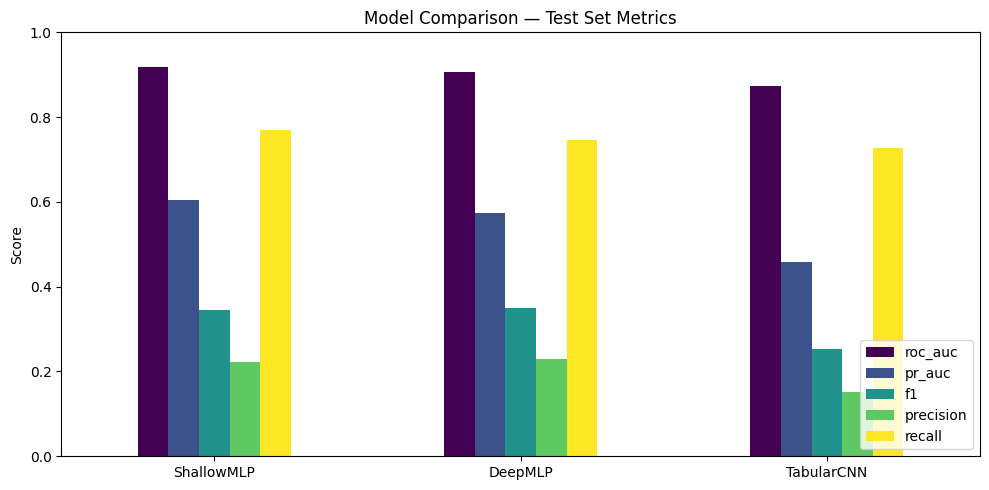

In [59]:
# Bar chart comparison of key metrics
metrics_to_plot = ["roc_auc", "pr_auc", "f1", "precision", "recall"]

fig, ax = plt.subplots(figsize=(10, 5))
summary_df[metrics_to_plot].plot(kind="bar", ax=ax, colormap="viridis")
plt.title("Model Comparison — Test Set Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


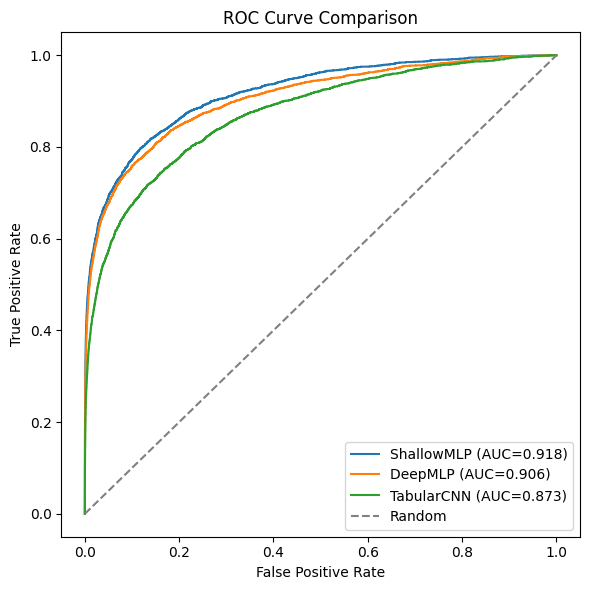

In [60]:
# ROC Curves — overlaid
plt.figure(figsize=(6,6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(res["test_targets"], res["test_probs"])
    auc_val = res["test_metrics"]["roc_auc"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


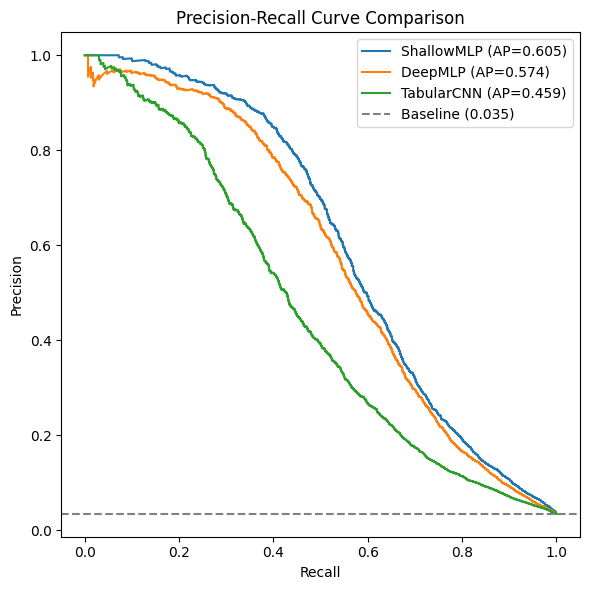

In [61]:
# Precision-Recall Curves — overlaid (most informative under class imbalance)
plt.figure(figsize=(6,6))
for name, res in results.items():
    precision, recall, _ = precision_recall_curve(res["test_targets"], res["test_probs"])
    ap = res["test_metrics"]["pr_auc"]
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

baseline_rate = y_test.mean()
plt.axhline(baseline_rate, linestyle="--", color="gray", label=f"Baseline ({baseline_rate:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


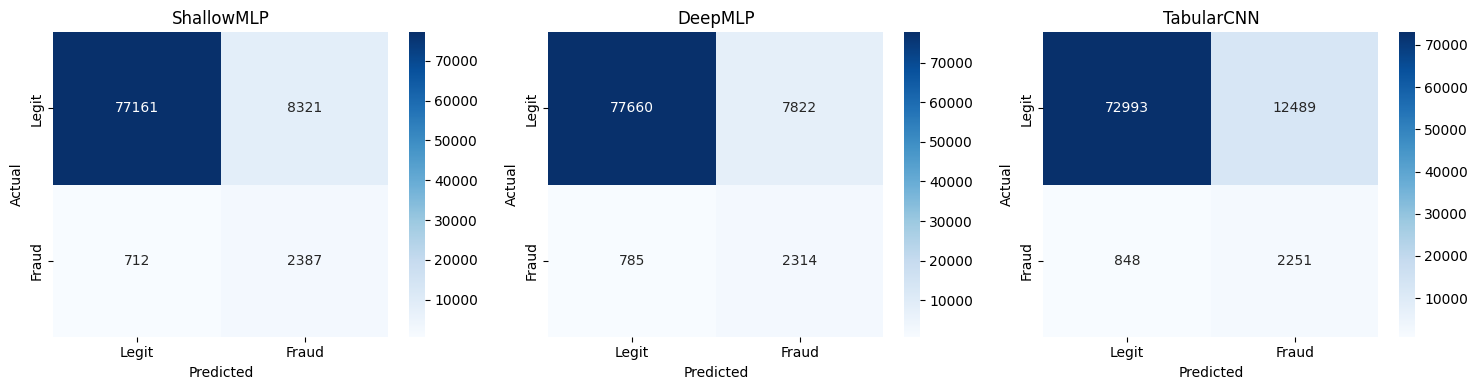

In [62]:
# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    y_pred = (res["test_probs"] >= 0.5).astype(int)
    cm = confusion_matrix(res["test_targets"], y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


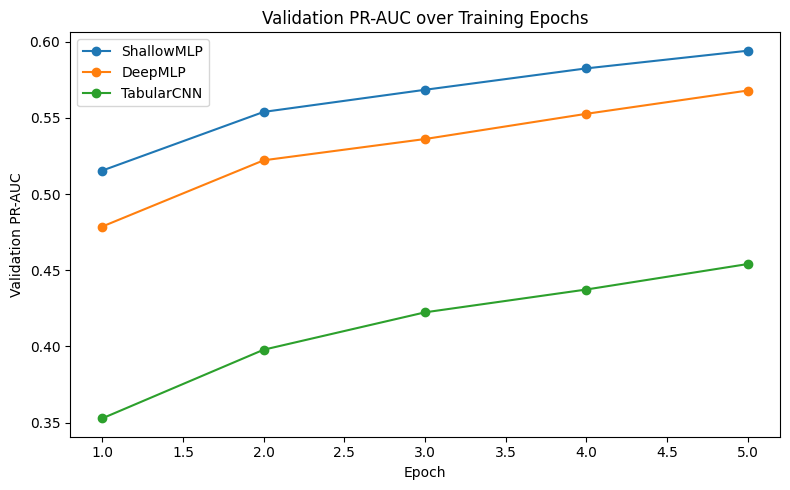

In [63]:
# Training curves (validation PR-AUC over epochs) for all 3 models
plt.figure(figsize=(8,5))
for name, res in results.items():
    hist_df = pd.DataFrame(res["history"])
    plt.plot(hist_df["epoch"], hist_df["pr_auc"], marker="o", label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation PR-AUC")
plt.title("Validation PR-AUC over Training Epochs")
plt.legend()
plt.tight_layout()
plt.show()


In [64]:
# Best hyperparameters found by Optuna for each model
for name, res in results.items():
    print(f"\n{name} — Best hyperparameters (Optuna):")
    for k, v in res["best_params"].items():
        print(f"   {k}: {v}")



ShallowMLP — Best hyperparameters (Optuna):
   lr: 0.0015958573588141277
   weight_decay: 1.1527987128232402e-06
   dropout: 0.4879639408647978
   batch_size: 256
   hidden_dim: 128

DeepMLP — Best hyperparameters (Optuna):
   lr: 0.00043284502212938834
   weight_decay: 0.0007114476009343421
   dropout: 0.39279757672456206
   batch_size: 256
   hidden_dim: 128
   n_layers: 5

TabularCNN — Best hyperparameters (Optuna):
   lr: 0.0015958573588141277
   weight_decay: 1.1527987128232402e-06
   dropout: 0.4879639408647978
   batch_size: 256
   n_filters: 64


---
## 11. Inspecting MLflow Runs Programmatically

Instead of (or in addition to) the MLflow UI, we can also query the tracking store directly from the notebook to confirm everything was logged correctly.


In [65]:
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name(EXPERIMENT_NAME)
runs = client.search_runs(experiment_ids=[experiment.experiment_id], order_by=["start_time DESC"])

print(f"Found {len(runs)} MLflow runs in experiment '{EXPERIMENT_NAME}':\n")
for r in runs:
    name = r.data.params.get("model_name", "unknown")
    pr_auc = r.data.metrics.get("test_pr_auc", float('nan'))
    roc_auc = r.data.metrics.get("test_roc_auc", float('nan'))
    print(f"  run_id={r.info.run_id[:8]}... | model={name:12s} | test_pr_auc={pr_auc:.4f} | test_roc_auc={roc_auc:.4f}")


Found 5 MLflow runs in experiment 'fraud_detection_deep_learning':

  run_id=e2256280... | model=TabularCNN   | test_pr_auc=0.4587 | test_roc_auc=0.8727
  run_id=b91bc1ed... | model=DeepMLP      | test_pr_auc=0.5742 | test_roc_auc=0.9062
  run_id=a2a4d32f... | model=ShallowMLP   | test_pr_auc=0.6052 | test_roc_auc=0.9181
  run_id=2022f17a... | model=ShallowMLP   | test_pr_auc=0.6052 | test_roc_auc=0.9181
  run_id=e57b6de0... | model=ShallowMLP   | test_pr_auc=0.6052 | test_roc_auc=0.9181


In [66]:
# To browse the full MLflow UI from your local machine instead of Colab:
# 1. Download the mlruns folder
!zip -rq mlruns.zip mlruns
print("Saved mlruns.zip — download it and run `mlflow ui` locally in the same folder to browse the UI.")

from google.colab import files
files.download("mlruns.zip")


Saved mlruns.zip — download it and run `mlflow ui` locally in the same folder to browse the UI.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 12. Saving the Best Model

We identify the overall best-performing architecture (by test PR-AUC, the most appropriate metric given the class imbalance) and save its weights for future use/deployment.


In [67]:
best_model_name = summary_df.index[0]
best_model = trained_models[best_model_name]

print(f"🏆 Best performing model: {best_model_name}")
print(summary_df.loc[best_model_name])

SAVE_PATH = os.path.join(DATA_DIR, f"best_model_{best_model_name}.pt")
torch.save(best_model.state_dict(), SAVE_PATH)
print(f"\nModel weights saved to: {SAVE_PATH}")


🏆 Best performing model: ShallowMLP
roc_auc      0.918085
pr_auc       0.605169
f1           0.345767
precision    0.222917
recall       0.770248
loss         0.307910
Name: ShallowMLP, dtype: float64

Model weights saved to: /content/drive/MyDrive/fraud_dataset/best_model_ShallowMLP.pt


---
## 13. Conclusions & Analysis

> ✍️ **Fill this section in after running the full pipeline on your machine** — replace the placeholders below with the actual numbers/observations from your run, since results depend on the random seed, Optuna trials, and Colab GPU/CPU runtime.

### 13.1 Summary of Results

| Model | ROC-AUC | PR-AUC | F1 | Precision | Recall |
|---|---|---|---|---|---|
| Shallow MLP | `<fill in>` | `<fill in>` | `<fill in>` | `<fill in>` | `<fill in>` |
| Deep MLP | `<fill in>` | `<fill in>` | `<fill in>` | `<fill in>` | `<fill in>` |
| 1D-CNN Tabular | `<fill in>` | `<fill in>` | `<fill in>` | `<fill in>` | `<fill in>` |

*(You can copy these directly from the `summary_df` table printed in Section 10.)*

### 13.2 Discussion points to address in your own write-up
- **Which architecture performed best, and why might that be?** (e.g., did extra depth in Model B help or cause overfitting given the dataset size? did the 1D-CNN's local-interaction inductive bias help or hurt on tabular features that have no natural ordering?)
- **Trade-offs observed**: training time, number of parameters, and stability across Optuna trials for each architecture.
- **Effect of class imbalance handling**: how did the `WeightedRandomSampler` affect Recall vs Precision compared to what you'd expect from training without it?
- **Business interpretation**: in fraud detection, **Recall** (catching fraud) is often prioritized over Precision (avoiding false alarms) — discuss whether your best model's threshold (0.5) is appropriate, or whether the threshold should be tuned using the Precision-Recall curve for a specific business cost trade-off.
- **Limitations**: feature engineering was relatively basic (median imputation, ordinal encoding); discuss what richer feature engineering (e.g., aggregation features, frequency encoding, time-based features) might improve further.

### 13.3 Final Takeaway
`<Write 2-4 sentences summarizing what you learned from comparing these three deep learning architectures on this fraud detection task, and which one you would recommend for production use and why.>`
